# Hướng 3: Optuna Hyperparameter Tuning

# 1. Load Data & Baseline V2

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)
from xgboost import XGBClassifier

# --- Load data ---
with open(r'C:\Code_AI\CS114-FinalTerm\FeatureEngineering\V2\output\feature_config_v2.json', 'r') as f:
    config = json.load(f)

FEATURES = config['feature_set_v2']
LABEL = config['label']

train_df = pd.read_csv(r'C:\Code_AI\CS114-FinalTerm\FeatureEngineering\V2\output\eval_train_v2.csv')
test_df = pd.read_csv(r'C:\Code_AI\CS114-FinalTerm\FeatureEngineering\V2\output\eval_test_v2.csv')

X_train, y_train = train_df[FEATURES], train_df[LABEL]
X_test, y_test = test_df[FEATURES], test_df[LABEL]

print(f'X_train: {X_train.shape} | Home Win: {y_train.mean():.1%}')
print(f'X_test:  {X_test.shape}  | Home Win: {y_test.mean():.1%}')
print(f'Features: {len(FEATURES)} cột')

X_train: (4852, 20) | Home Win: 55.4%
X_test:  (1137, 20)  | Home Win: 54.7%
Features: 20 cột


In [4]:
# --- Baseline models (tái tạo V2) ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

xgb_baseline = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.05,
    random_state=42, eval_metric='logloss'
)
xgb_baseline.fit(X_train, y_train)

# Hàm đánh giá
def evaluate(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    f1_home = f1_score(y_true, y_pred)
    f1_away = f1_score(y_true, y_pred, pos_label=0)
    report = classification_report(y_true, y_pred, target_names=['Away Win', 'Home Win'], output_dict=True)
    recall_away = report['Away Win']['recall']
    recall_home = report['Home Win']['recall']
    
    print(f'--- {name} ---')
    print(f'  Accuracy:     {acc:.4f}')
    print(f'  ROC-AUC:      {auc:.4f}')
    print(f'  F1 Home:      {f1_home:.4f}')
    print(f'  F1 Away:      {f1_away:.4f}')
    print(f'  Recall Home:  {recall_home:.4f}')
    print(f'  Recall Away:  {recall_away:.4f}')
    
    return {'name': name, 'accuracy': acc, 'roc_auc': auc,
            'f1_home': f1_home, 'f1_away': f1_away,
            'recall_home': recall_home, 'recall_away': recall_away}

print('BASELINE V2:')
print('=' * 50)
results = []

lr_proba = lr_model.predict_proba(X_test)[:, 1]
lr_pred = lr_model.predict(X_test)
results.append(evaluate('LR Baseline', y_test, lr_pred, lr_proba))

print()
xgb_proba = xgb_baseline.predict_proba(X_test)[:, 1]
xgb_pred = xgb_baseline.predict(X_test)
results.append(evaluate('XGB Baseline', y_test, xgb_pred, xgb_proba))

BASELINE V2:
--- LR Baseline ---
  Accuracy:     0.6702
  ROC-AUC:      0.7204
  F1 Home:      0.7118
  F1 Away:      0.6146
  Recall Home:  0.7444
  Recall Away:  0.5806

--- XGB Baseline ---
  Accuracy:     0.6684
  ROC-AUC:      0.7150
  F1 Home:      0.7133
  F1 Away:      0.6069
  Recall Home:  0.7540
  Recall Away:  0.5650


# 2. Optuna Hyperparameter Tuning cho XGBoost
### Tune gì?
- `max_depth`: 2-6 (tránh overfitting)
- `min_child_weight`: 1-10 (chống nhiễu dữ liệu thể thao)
- `subsample`: 0.6-1.0 (đa dạng hóa)
- `colsample_bytree`: 0.6-1.0 (giảm phụ thuộc vào DIFF_ELO)
- `learning_rate`: 0.01-0.3
- `n_estimators`: 50-500
- `gamma`: 0-5 (regularization)
- `reg_alpha`, `reg_lambda`: regularization L1/L2


In [5]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """Optuna objective: maximize CV accuracy trên tập train."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'gamma': trial.suggest_float('gamma', 0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'eval_metric': 'logloss',
    }
    
    model = XGBClassifier(**params)
    
    # 5-fold stratified CV trên tập train
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    
    return scores.mean()

# Chạy Optuna
print('Đang chạy Optuna (100 trials)...')
print('Mỗi trial = 5-fold CV trên tập train → không dùng test set')
print('-' * 50)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nHoàn thành {len(study.trials)} trials')
print(f'Best CV Accuracy: {study.best_value:.4f}')
print(f'\nBest hyperparameters:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Đang chạy Optuna (100 trials)...
Mỗi trial = 5-fold CV trên tập train → không dùng test set
--------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]


Hoàn thành 100 trials
Best CV Accuracy: 0.6424

Best hyperparameters:
  n_estimators: 50
  max_depth: 2
  min_child_weight: 10
  subsample: 0.7372165949737446
  colsample_bytree: 0.6955973390152621
  learning_rate: 0.10382153801007143
  gamma: 0.4787620023299419
  reg_alpha: 1.521432792045549e-06
  reg_lambda: 8.294636293762082e-06


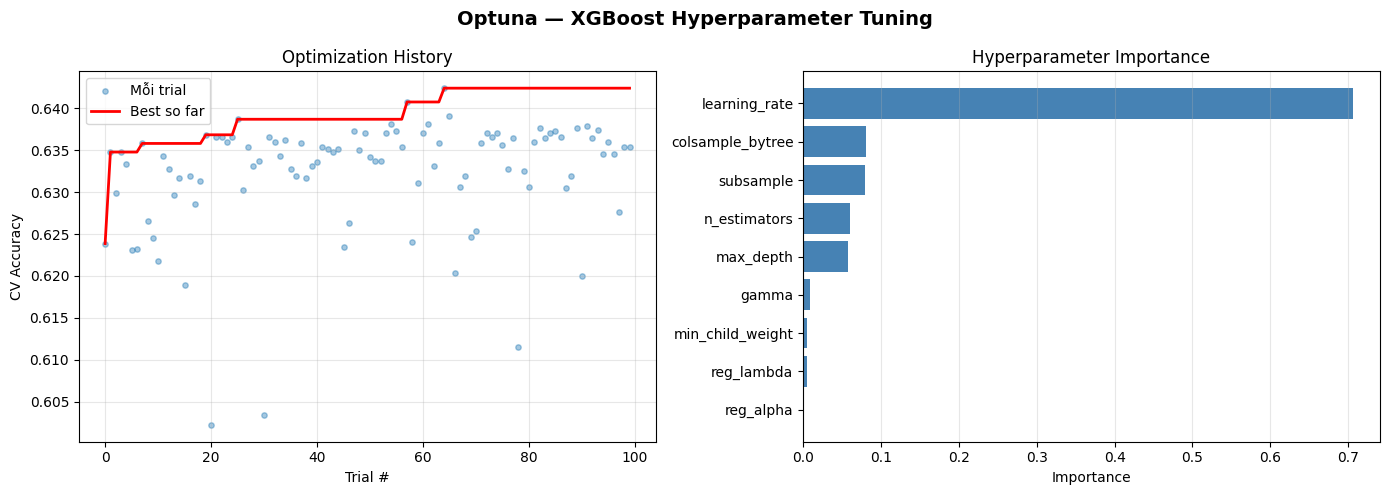

In [7]:
# Visualize Optuna results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Optimization History
trial_numbers = [t.number for t in study.trials]
trial_values = [t.value for t in study.trials]
best_so_far = np.maximum.accumulate(trial_values)

axes[0].scatter(trial_numbers, trial_values, alpha=0.4, s=15, label='Mỗi trial')
axes[0].plot(trial_numbers, best_so_far, 'r-', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial #')
axes[0].set_ylabel('CV Accuracy')
axes[0].set_title('Optimization History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Top 10 hyperparameter importance
importance = optuna.importance.get_param_importances(study)
params_sorted = sorted(importance.items(), key=lambda x: x[1], reverse=True)
param_names = [p[0] for p in params_sorted]
param_values = [p[1] for p in params_sorted]

axes[1].barh(param_names[::-1], param_values[::-1], color='steelblue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importance')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Optuna — XGBoost Hyperparameter Tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Train XGBoost với best params → đánh giá trên test set
print('ĐÁNH GIÁ XGB OPTUNA TRÊN TEST SET')
print('=' * 50)

best_params = study.best_params
best_params['random_state'] = 42
best_params['eval_metric'] = 'logloss'

xgb_optuna = XGBClassifier(**best_params)
xgb_optuna.fit(X_train, y_train)

xgb_opt_proba = xgb_optuna.predict_proba(X_test)[:, 1]
xgb_opt_pred = xgb_optuna.predict(X_test)

results.append(evaluate('XGB Optuna', y_test, xgb_opt_pred, xgb_opt_proba))

ĐÁNH GIÁ XGB OPTUNA TRÊN TEST SET
--- XGB Optuna ---
  Accuracy:     0.6728
  ROC-AUC:      0.7231
  F1 Home:      0.7160
  F1 Away:      0.6141
  Recall Home:  0.7540
  Recall Away:  0.5748


In [9]:
# Bảng so sánh tất cả phiên bản
compare_df = pd.DataFrame(results)
compare_df = compare_df.set_index('name')

# Format đẹp
print('BẢNG SO SÁNH TỔNG HỢP')
print('=' * 90)
print(compare_df.to_string(float_format='{:.4f}'.format))

# Highlight best
print(f'\n🏆 Best Accuracy:    {compare_df["accuracy"].idxmax()} ({compare_df["accuracy"].max():.4f})')
print(f'🏆 Best ROC-AUC:     {compare_df["roc_auc"].idxmax()} ({compare_df["roc_auc"].max():.4f})')
print(f'🏆 Best Recall Away: {compare_df["recall_away"].idxmax()} ({compare_df["recall_away"].max():.4f})')

BẢNG SO SÁNH TỔNG HỢP
              accuracy  roc_auc  f1_home  f1_away  recall_home  recall_away
name                                                                       
LR Baseline     0.6702   0.7204   0.7118   0.6146       0.7444       0.5806
XGB Baseline    0.6684   0.7150   0.7133   0.6069       0.7540       0.5650
XGB Optuna      0.6728   0.7231   0.7160   0.6141       0.7540       0.5748

🏆 Best Accuracy:    XGB Optuna (0.6728)
🏆 Best ROC-AUC:     XGB Optuna (0.7231)
🏆 Best Recall Away: LR Baseline (0.5806)
